In [9]:
import ruptures as rpt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.signal import detrend
import warnings
from matplotlib import gridspec
from scipy.stats import levene
from PyEMD import EMD

In [2]:
file = '../data/mice_data.xlsx'
sheets = ['FemTemp', 'FemAct', 'MaleTemp', 'MaleAct']

data = {s:pd.read_excel(file, sheet_name = s, index_col = 0) for s in sheets}
for key, df in data.items():
    df.index = df.index / (60 * 24)

In [3]:
def preprocess(df):
    df = df.apply(detrend, axis=0)
    df = (df - df.mean()) / df.std()
    return df
processed_data = data
for key in data:
    processed_data[key] = preprocess(data[key])

Female variance (Light vs Dark):
Light    0.476011
Dark     0.611058
dtype: float64

Male variance (Light vs Dark):
Light    0.617367
Dark     0.650323
dtype: float64


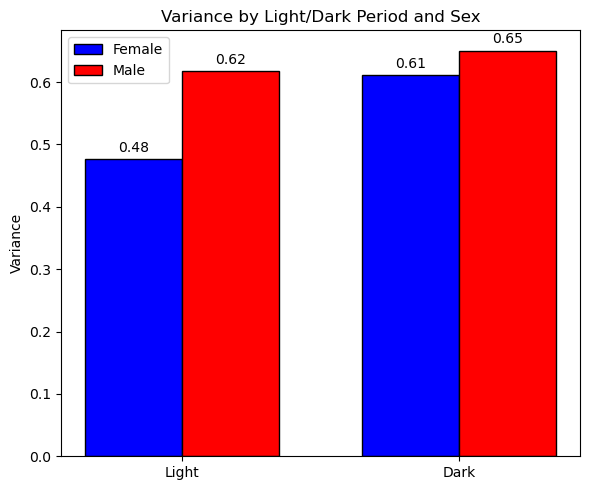

In [4]:

# Define dark/light periods (first 12h = dark, next 12h = light)
minutes_per_day = 24 * 60
dark_hours = 12
light_hours = 12

def get_light_dark_masks(df):
    # Convert index in days to minutes within day
    minutes_in_day = (df.index * 24 * 60) % minutes_per_day
    dark_mask = minutes_in_day < (dark_hours * 60)
    light_mask = ~dark_mask
    return light_mask, dark_mask

def compute_variance_by_light_dark(df):
    light_mask, dark_mask = get_light_dark_masks(df)
    light_var = df[light_mask].var()
    dark_var = df[dark_mask].var()
    return pd.DataFrame({'Light': light_var, 'Dark': dark_var})

# Separate processed data by sex
females = processed_data['FemTemp']  # or 'FemAct' if you want activity
males = processed_data['MaleTemp']

# Compute variance
female_var = compute_variance_by_light_dark(females)
male_var = compute_variance_by_light_dark(males)

# Compute mean variance across mice
female_summary = female_var.mean()
male_summary = male_var.mean()

print("Female variance (Light vs Dark):")
print(female_summary)
print("\nMale variance (Light vs Dark):")
print(male_summary)

# Prepare data
labels = ['Light', 'Dark']
female_values = [female_summary['Light'], female_summary['Dark']]
male_values = [male_summary['Light'], male_summary['Dark']]

x = np.arange(len(labels))  # the label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(6,5))
rects1 = ax.bar(x - width/2, female_values, width, label='Female', color='blue', edgecolor='black')
rects2 = ax.bar(x + width/2, male_values, width, label='Male', color='red', edgecolor='black')

# Add labels, title, and legend
ax.set_ylabel('Variance')
ax.set_title('Variance by Light/Dark Period and Sex')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Optional: annotate bars with values
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


C:\Users\matt3\AppData\Local\Temp\ipykernel_84588\3539666523.py:100: RuntimeWarning: Mean of empty slice
  male_light_mean = np.nanmean(male_light, axis=0)
C:\Users\matt3\AppData\Local\Temp\ipykernel_84588\3539666523.py:101: RuntimeWarning: Mean of empty slice
  male_dark_mean = np.nanmean(male_dark, axis=0)


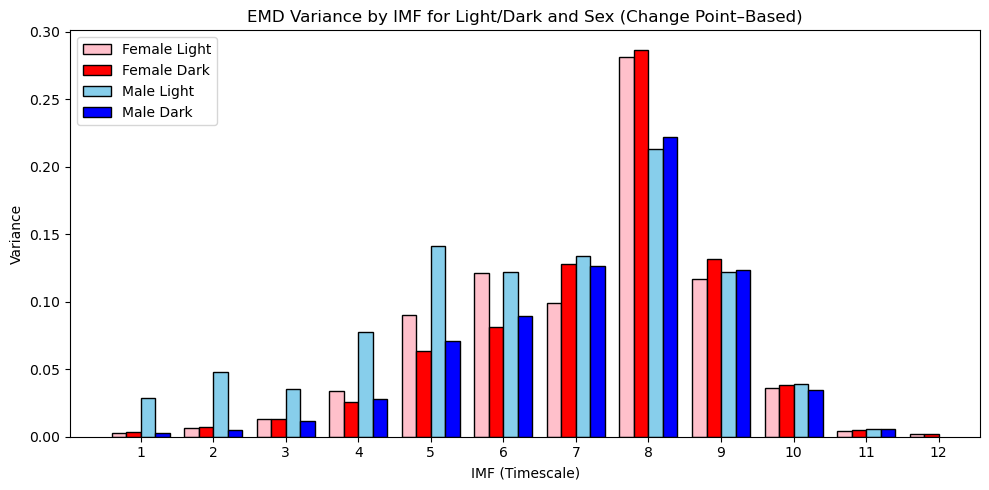

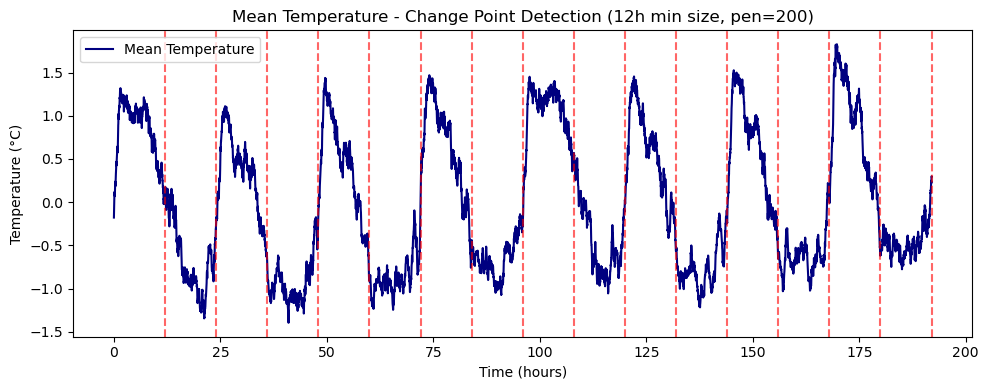

'\nIMF 1: ~0.08 hours\nIMF 2: ~0.15 hours\nIMF 3: ~0.31 hours\nIMF 4: ~0.68 hours\nIMF 5: ~1.44 hours\nIMF 6: ~3.43 hours\nIMF 7: ~7.40 hours\nIMF 8: ~21.48 hours\nIMF 9: ~48.64 hours\nIMF 10: ~98.88 hours\nIMF 11: ~nan hours\n'

In [10]:
def get_light_dark_masks_rpt(df, pen=200, min_hours=12):
    """
    Use change-point detection (ruptures) on mean temperature to create light/dark masks.
    Returns boolean arrays: light_mask, dark_mask (same length as df).
    """
    # Mean temperature across mice
    temp_mean = df.mean(axis=1)

    # Convert time index to hours (assuming 1 sample per minute)
    time_hours = np.arange(len(temp_mean)) / 60
    min_size = int(min_hours * 60)  # convert to samples

    # Run change point detection
    algo = rpt.Pelt(model="l2", min_size=min_size).fit(temp_mean.to_numpy().reshape(-1, 1))
    result = algo.predict(pen=pen)

    # Create alternating light/dark masks
    light_mask = np.zeros(len(temp_mean), dtype=bool)
    dark_mask = np.zeros(len(temp_mean), dtype=bool)

    start = 0
    is_dark = True  # assume first segment is dark
    for cp in result:
        if is_dark:
            dark_mask[start:cp] = True
        else:
            light_mask[start:cp] = True
        is_dark = not is_dark
        start = cp

    return light_mask, dark_mask, time_hours, temp_mean, result


def emd_variance(signal):
    """Perform EMD and return variance of each IMF."""
    emd = EMD()
    imfs = emd(signal)
    var_list = [np.var(imf) for imf in imfs]
    return imfs, var_list


def pad_to_max(arr, max_len):
    """Pad each row of arr with NaN to have max_len columns."""
    n_rows, n_cols = arr.shape
    if n_cols < max_len:
        padded = np.full((n_rows, max_len), np.nan)
        padded[:, :n_cols] = arr
        return padded
    return arr


def variance_by_light_dark(df, pen=200):
    """Compute variance per IMF for light vs dark periods using change point detection."""
    light_mask, dark_mask, _, _, _ = get_light_dark_masks_rpt(df, pen=pen)

    # First pass: find maximum number of IMFs
    max_imfs = 0
    for col in df.columns:
        imfs, _ = emd_variance(df[col].values)
        if len(imfs) > max_imfs:
            max_imfs = len(imfs)

    # Compute variance for each mouse
    light_vars = []
    dark_vars = []

    for col in df.columns:
        signal = df[col].values
        imfs, _ = emd_variance(signal)
        padded_light = np.full(max_imfs, np.nan)
        padded_dark = np.full(max_imfs, np.nan)
        for j, imf in enumerate(imfs):
            padded_light[j] = np.var(imf[light_mask])
            padded_dark[j] = np.var(imf[dark_mask])
        light_vars.append(padded_light)
        dark_vars.append(padded_dark)

    return np.array(light_vars), np.array(dark_vars), light_mask, dark_mask


females = processed_data['FemTemp']
males = processed_data['MaleTemp']

female_light, female_dark, fem_light_mask, fem_dark_mask = variance_by_light_dark(females, pen=200)
male_light, male_dark, _, _ = variance_by_light_dark(males, pen=200)

# Find maximum IMF count
max_imfs = max(female_light.shape[1], female_dark.shape[1],
               male_light.shape[1], male_dark.shape[1])

# Pad all arrays to same length
female_light = pad_to_max(female_light, max_imfs)
female_dark = pad_to_max(female_dark, max_imfs)
male_light = pad_to_max(male_light, max_imfs)
male_dark = pad_to_max(male_dark, max_imfs)

# Compute mean across mice
female_light_mean = np.nanmean(female_light, axis=0)
female_dark_mean = np.nanmean(female_dark, axis=0)
male_light_mean = np.nanmean(male_light, axis=0)
male_dark_mean = np.nanmean(male_dark, axis=0)

imfs = np.arange(1, max_imfs + 1)
width = 0.2

plt.figure(figsize=(10,5))
plt.bar(imfs - width*1.5, female_light_mean, width, label='Female Light', color='pink', edgecolor='black')
plt.bar(imfs - width/2, female_dark_mean, width, label='Female Dark', color='red', edgecolor='black')
plt.bar(imfs + width/2, male_light_mean, width, label='Male Light', color='skyblue', edgecolor='black')
plt.bar(imfs + width*1.5, male_dark_mean, width, label='Male Dark', color='blue', edgecolor='black')
plt.xlabel('IMF (Timescale)')
plt.ylabel('Variance')
plt.title('EMD Variance by IMF for Light/Dark and Sex (Change Point–Based)')
plt.xticks(imfs)
plt.legend()
plt.tight_layout()
plt.show()


_, _, time_hours, temp_mean, result = get_light_dark_masks_rpt(females, pen=200)
plt.figure(figsize=(10,4))
plt.plot(time_hours, temp_mean, label="Mean Temperature", color="navy")
for cp in result:
    plt.axvline(time_hours[cp - 1], color="red", linestyle="--", alpha=0.6)
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (°C)")
plt.title("Mean Temperature - Change Point Detection (12h min size, pen=200)")
plt.tight_layout()
plt.legend()
plt.show()
"""
IMF 1: ~0.08 hours
IMF 2: ~0.15 hours
IMF 3: ~0.31 hours
IMF 4: ~0.68 hours
IMF 5: ~1.44 hours
IMF 6: ~3.43 hours
IMF 7: ~7.40 hours
IMF 8: ~21.48 hours
IMF 9: ~48.64 hours
IMF 10: ~98.88 hours
IMF 11: ~nan hours
"""